In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
protein_name = "trp_cage"

In [5]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")

device = torch.device(torch.cuda.current_device())

# Load the MD data

gen_mode = "om_interpolate" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = "test_md" # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

md_samples_path = os.path.join(eval_folder, f"sample-{gen_mode}-md.pt")
om_points_path = os.path.join(eval_folder, f"sample-{gen_mode}.pt")
md_samples = torch.load(md_samples_path)
om_points = torch.load(om_points_path)

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}.npy",
    )
)
tic_cluster_coords = np.load(cluster_centers_path)

iid_sample_path = Path(os.path.join(os.path.dirname(eval_folder), "main_eval_output_iid"))
# Get TICA
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=iid_sample_path,
    data_folder="datasets",
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)
# assign TIC cluster centers to the reference samples
tic_cluster_assignments, transformed_samples = discretize_trajectory(
    md_samples, tic_evaluator, tic_cluster_coords
)

tic_cluster_assignments = torch.tensor(tic_cluster_assignments)


n_atoms = md_samples.shape[1]





/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:206: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


In [12]:
# compute assignments of trajectories to clusters defined by OM path waypoints
def nullspace(A, atol=1e-13, rtol=0):
    #Helper function to obtain null space
    A = np.atleast_2d(A)
    u, s, vh = np.linalg.svd(A)
    tol = max(atol, rtol * s[0])
    nnz = (s >= tol).sum()
    ns = vh[nnz:].conj().T
    ss = s[nnz:]
    return ns, ss

def compute_reweighting_factors(Kmatrix, tol=2e-9):
    """Adapted from https://github.com/muhammadhasyim/tps-torch
    Computes the reweighting factor z_l for each node point by solving an eigenvalue problem
        
    Args:
        Kmatrix (torch.Tensor): [n_path_points, n_path_points] tensor of transition rates between path points during MD simulation.
        tol (float): Tolerance value for the off-diagonal elements of the Kmatrix. Default is 2e-9.
    See Appendix A of paper 
    https://pubs.aip.org/aip/jcp/article/157/18/184111/2842057/Supervised-learning-and-the-finite-temperature for more details.
    """
    
    N = Kmatrix.shape[0]
	#Add tolerance values to the off-diagonal elements
    for i in range(N):
        for j in range(N):
            if abs(i-j) == 1:
                Kmatrix[i, j] += tol
        
    #Build the final matrix
    Kmatrix = Kmatrix.t()-torch.diag(torch.sum(Kmatrix,dim=1)-tol)
    #Compute the reweighting factors using an eigensolver
    v, w = nullspace(Kmatrix.numpy(), atol=tol)
    try:
        index = np.argmin(w)
        zl = np.real(v[:,index])
    except:
        print("Failed")
        #Shift value may not be small enough so we choose a default higher tolerance detection
        v, w = nullspace(Kmatrix.numpy(), atol=10**(-5), rtol=0)
        index = np.argmin(w)
        zl = np.real(v[:,index])
    
    #Normalize
    zl /= np.sum(zl)  
    return zl


#Assign OM clusters to each frame based on distances to the OM optimized paths
md_samples = md_samples.to(device)[:10000]
om_points = om_points.to(device)
distances = torch.linalg.norm(md_samples.unsqueeze(1) - om_points.unsqueeze(0), dim=-1)
om_cluster_assignments = torch.argmin(distances, dim=1)

# Compute transition counts between OM clusters
n_clusters = len(om_points)
transition_counts = torch.zeros((n_clusters, n_clusters)).to(device)
print("Computing transition rates between OM path waypoints")
om_cluster_assignments = om_cluster_assignments.reshape(-1, 1000)
for traj in tqdm(range(om_cluster_assignments.shape[0])):
    for i in range(1, om_cluster_assignments.shape[1]):
        transition_counts[om_cluster_assignments[traj, i-1], om_cluster_assignments[traj, i]] += 1

# Remove clusters that have no population

# Compute reweighting factors based on the OM cluster assignments 


Computing transition rates between OM path waypoints


100%|██████████| 200/200 [00:27<00:00,  7.23it/s]


In [ ]:
# Plot the TICA space with black points and red 'x' markers for cluster centers
plt.figure()
plt.scatter(transformed_samples[::100, 0], transformed_samples[::100, 1], c='black', s=10)
plt.scatter(tic_cluster_coords[:, 0], tic_cluster_coords[:, 1], c='red', s=200, marker='x', label='Cluster Centers')

# Add a text label above each cluster center with its index
for i, (x, y) in enumerate(tic_cluster_coords):
    plt.text(x, y, str(i), color='cyan', fontsize=10, ha='center')

# Set plot title and axis labels
plt.title("TIC Space")
plt.xlabel("TIC 1")
plt.ylabel("TIC 2")

# Show the plot
plt.legend()
plt.show()

In [22]:
def get_gt_rate(tic_samples, start_cluster, end_cluster, clusters, tic):
    n_samples = tic_samples.shape[0]
    
    # Digitize samples into bins
    bins_x = np.digitize(tic_samples[:, 0], tic.bin_edges_x) - 1
    bins_y = np.digitize(tic_samples[:, 1], tic.bin_edges_y) - 1
    
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, tic.bins - 1)
    bins_y = np.clip(bins_y, 0, tic.bins - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * tic.bins + bins_y

    if os.path.exists(f"./evaluate/saved_references/{protein_name}_gt_rate_{start_cluster}_{end_cluster}.npy"):
        gt_rate = np.load(f"./evaluate/saved_references/{protein_name}_gt_rate_{start_cluster}_{end_cluster}.npy")
        return gt_rate
    
    # Initialize committor probabilities tensor
    first_passage_times = []
    
    # Boolean masks for start and end cluster transitions
    is_start = (clusters == start_cluster)
    is_end = (clusters == end_cluster)
    
    last_committor = None
    last_transition_idx = None

    # Iterate over samples to assign committor probabilities
    i=0
    count=0
    while i < n_samples:
        if is_start[i]:  # Found a start state
            subsequent_clusters = clusters[i:]  

            # Check if a transition exists
            if (subsequent_clusters == end_cluster).any():              
                first_end = np.argmax(subsequent_clusters == end_cluster)  # Find first passage
                # Create an array of indices in the range [i, i + first_end]
                valid_start_indices = np.arange(i, i + first_end + 1)[is_start[i:i + first_end + 1]]
                # Compute passage times using vectorized operations
                passage_times = 0.2 * (i + first_end - valid_start_indices)
                # Efficiently extend the list in one operation
                first_passage_times.extend(passage_times)
                i += first_end  # Skip ahead to the next relevant point
            else:
                break  # No valid transition found, exit
        else:
            i += 1  # Skip non-start states
        count +=1
            
    
    first_passage_time = np.mean(np.array(first_passage_times))
    rate = 1 / first_passage_time
                
    # Save rates
    np.save(f"./evaluate/saved_references/{protein_name}_gt_rate_{start_cluster}_{end_cluster}.npy", rate)
    
    return rate

# Direct Counting 
start, end = CLUSTER_ENDPOINTS[protein_name]
rate = get_gt_rate(transformed_samples, start, end, cluster_assignments, tic_evaluator)
print(f"Rate from direct counting: {rate} ns-1")

import numpy as np
import torch
from deeptime.markov.tools.analysis import mfpt
prob_mat = np.load(f"./evaluate/saved_references/saved_transition_matrix_{(protein_name).upper()}.npy")
fpt = mfpt(prob_mat, end, start, tau=0.2)
rate = 1 / fpt
print(f"Rate from MSM analysis: {rate} ns^-1")


Rate from direct counting: 0.00018911062602265633 ns-1
Rate from MSM analysis: 0.004010886571750448 ns^-1


100%|██████████| 25/25 [49:17<00:00, 118.30s/it]


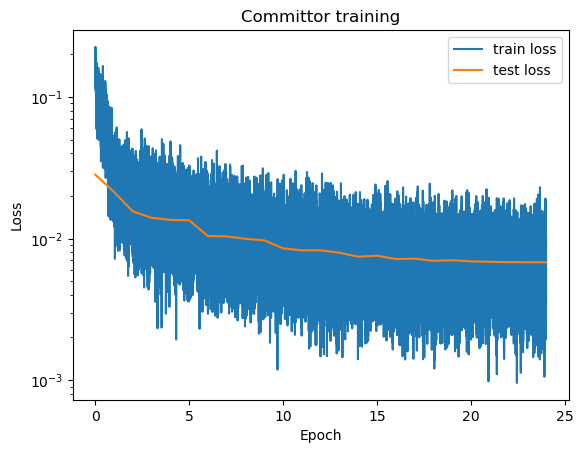

In [21]:
# Model training

model = GraphTransformer(num_beads = n_atoms, hidden_nf=64, conservative=True).to(device)

from models import CommittorNN


committor_model = CommittorNN(model)

# Train the model on the sampled molecules
batch_size = 64
n_epochs = 25
max_data_size = 100000
idxs = np.random.choice(md_samples.shape[0], max_data_size, replace=False)
optimizer = torch.optim.Adam(committor_model.parameters(), lr=1e-3)
scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 200, \
                                                        total_steps = n_epochs * int(0.8 * max_data_size / batch_size), \
                                                        lr_min=0.75, lr_max=1.0)
train_losses = []
test_losses = []

# split sampled_mol and cluster_assignments into train test sets
md_samples_keep = md_samples[idxs]
md_samples_keep = md_samples_keep - md_sampled_keep.mean(1, keepdims=True)

tic_cluster_assignments_keep = tic_cluster_assignments[idxs]
om_cluster_assignments_keep = om_cluster_assignments[idxs]

reweighting_factors_keep = reweighting_factors[idxs]

x_train, x_test, tic_cluster_train, tic_cluster_test, om_cluster_train, om_cluster_test, weights_train, weights_test = train_test_split(md_samples_keep, tic_cluster_assignments_keep, om_cluster_assignments_keep, reweighting_factors_keep, test_size=0.2)
trainset = torch.utils.data.TensorDataset(x_train, tic_cluster_train, om_cluster_train, weights_train)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torch.utils.data.TensorDataset(x_test, tic_cluster_test, om_cluster_test, weights_test)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

for _ in tqdm(range(n_epochs)):
    committor_model.train()
    for x, tic_cluster, om_cluster, weight in train_dataloader:
        
        optimizer.zero_grad()
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        tic_cluster = tic_cluster.to(device)
        prob = prob.to(device)
        start_mask = tic_cluster == start
        end_mask = tic_cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        grad_loss = grad_prob.square().sum((-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()
        
        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss #5*start_boundary_loss + 5*end_boundary_loss + grad_loss #sl_loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.detach().unsqueeze(-1))
        
    # Test the model on the test set
    committor_model.eval()
    tls = []
    for x, tic_cluster, om_cluster, weight in test_dataloader:
        x = x.to(device).requires_grad_(True)
        x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
        tic_cluster = tic_cluster.to(device)
        prob = prob.to(device)
        start_mask = tic_cluster == start
        end_mask = tic_cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        pred_prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        grad_loss = grad_prob.square().sum((-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end_mask].mean()

        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss #5*start_boundary_loss + 5*end_boundary_loss + grad_loss
        tls.append(loss.detach().unsqueeze(-1))
    
    test_loss = torch.cat(tls).sum(0) / len(tls)
    test_losses.append(test_loss.unsqueeze(-1))


train_losses = torch.cat(train_losses).cpu().numpy()
test_losses = torch.cat(test_losses).cpu().numpy()

plot_losses(train_losses, test_losses, "Committor training")

# Save the model
torch.save(committor_model, f"./saved_models/{protein_name}/committor-model-{start}_{end}.pt")


  0%|          | 0/313 [00:00<?, ?it/s]

100%|██████████| 313/313 [00:06<00:00, 45.46it/s]


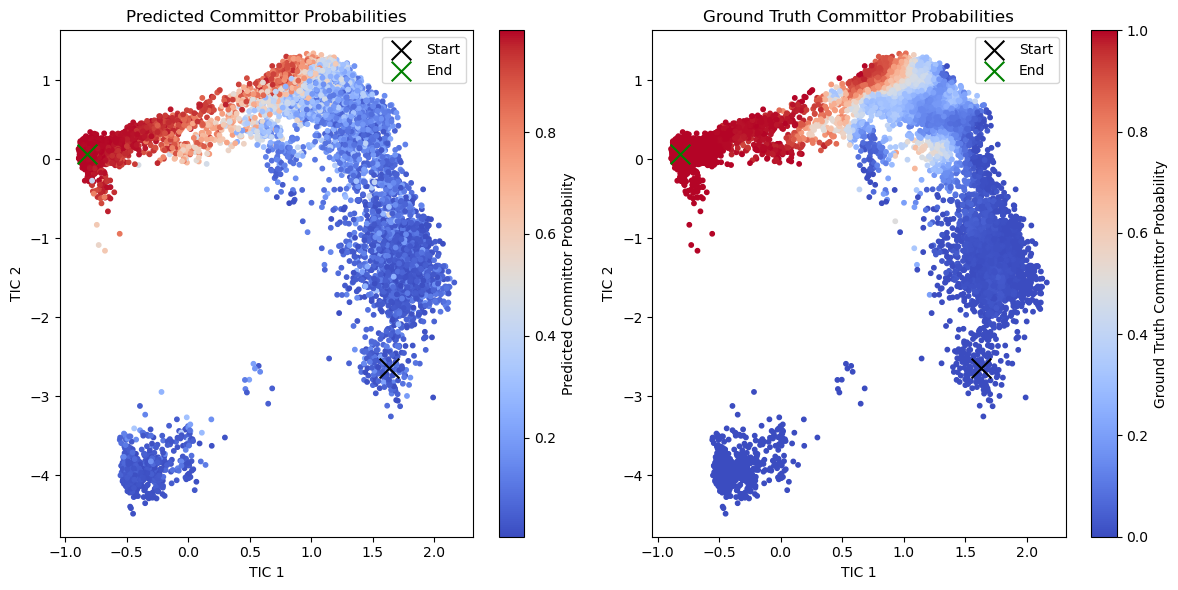

In [22]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Evaluate the committor model and get predicted probabilities
committor_model.eval()

committor_probs = []
for x in tqdm(x_test.split(batch_size)):
    x = x.to(device).requires_grad_(True)
    x = (x - x.mean(1, keepdim=True)) / norm_stds[Molecules[protein_name.upper()]]
    h = torch.eye(n_atoms).to(device)
    t = torch.zeros((x.shape[0], )).to(device)
    pred_prob = committor_model(x, h, t)
    committor_probs.append(pred_prob.detach())

committor_probs = torch.cat(committor_probs).cpu().detach().numpy()

# Get TICA for the ground truth data
sample_tic_features = tic_evaluator.get_tic_features(
        x_test, tic_evaluator.folded
    )
transformed_samples = tic_evaluator.tica(sample_tic_features)

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the predicted committor probabilities
scatter1 = axs[0].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=committor_probs, cmap='coolwarm', s=10)
axs[0].set_title('Predicted Committor Probabilities')
axs[0].set_xlabel('TIC 1')
axs[0].set_ylabel('TIC 2')
axs[0].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[0].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[0].legend()
plt.colorbar(scatter1, ax=axs[0], label='Predicted Committor Probability')

# Plot the ground truth committor probabilities
scatter2 = axs[1].scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=probs_test, cmap='coolwarm', s=10)
axs[1].set_title('Ground Truth Committor Probabilities')
axs[1].set_xlabel('TIC 1')
axs[1].set_ylabel('TIC 2')
axs[1].scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='black', s=200, marker='x', label='Start')
axs[1].scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='green', s=200, marker='x', label='End')
axs[1].legend()
plt.colorbar(scatter2, ax=axs[1], label='Ground Truth Committor Probability')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
